# Contextual Denoising Autoencoder - Learning an Arbitrary Association
This notebook trains a contextual denoising autoencoder on the MNIST dataset to simulate a neuroscience experiment that investigates the formation of a multisensory association. The goal is to explore how adding a "contextual" input (representing an additional sensory modality) consistently paired with specific visual categories can bias neural representations and behavior. In this setup, the model reconstructs images from noisy inputs and integrates contextual information to capture the association, providing a framework to generate predictions for the real experiment.

In [1]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import os
# to prevent crash due to MKL
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
# check if cuda is available
cuda_enabled = torch.cuda.is_available()
# print result
print("CUDA is enabled:", cuda_enabled)
# additional information if CUDA is enabled
if cuda_enabled:
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA current device:", torch.cuda.current_device())
    print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

CUDA is enabled: True
CUDA device count: 1
CUDA current device: 0
CUDA device name: NVIDIA RTX 2000 Ada Generation Laptop GPU


In [3]:
# set dark background for plots
plt.style.use('dark_background')

### MNIST Data Loading
MNIST images show digits from 0-9 in 28x28 grayscale images. We normalize and center them around 0, which gives a slight performance boost during training. We create both a training set and a test set. This time we will also add noise to the images to be reconstructed during training.

In [4]:
# set batch size
batch_size = 128
# set noise level for the context and training data
context_signal_level = 1.00  # signal level of the context
context_noise_level = 0.10  # noise level of the context
training_noise_level = 1.00  # noise level of the training data
# define preprocessing image transformation for MNIST dataset
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# load MNIST dataset, training set
train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# load MNIST dataset, testing set
test_dataset = MNIST(root='./data/MNIST', download=True, train=False, transform=img_transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

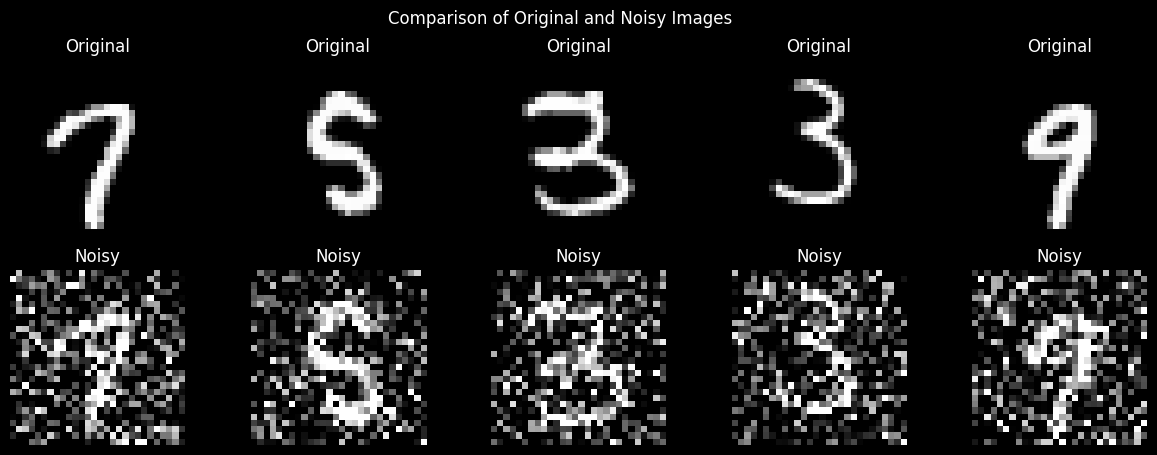

In [5]:
# Select a batch of images from the training data
images, _ = next(iter(train_dataloader))

# Function to add noise
def add_noise(images, noise_level=0.4):
    noisy_images = images + noise_level * torch.randn_like(images)
    return noisy_images.clamp(-1, 1)  # Clamp to keep values in range [-1, 1]

# Generate noisy images
noisy_images = add_noise(images, noise_level=training_noise_level)

# Helper function to display original and noisy images side by side
def visualize_noisy_images(original, noisy, num_images=5):
    original = original[:num_images].cpu()
    noisy = noisy[:num_images].cpu()
    
    fig, axs = plt.subplots(2, num_images, figsize=(15, 5))
    
    for i in range(num_images):
        # Original images
        axs[0, i].imshow(original[i].squeeze().numpy(), cmap='gray')
        axs[0, i].axis('off')
        axs[0, i].set_title("Original")

        # Noisy images
        axs[1, i].imshow(noisy[i].squeeze().numpy(), cmap='gray')
        axs[1, i].axis('off')
        axs[1, i].set_title("Noisy")
    
    plt.suptitle("Comparison of Original and Noisy Images")
    plt.show()

# Visualize the images to inspect level of noise corruption that will be used for training
visualize_noisy_images(images, noisy_images, num_images=5)

### Contextual Denoising Autoencoder Definition
In this notebook, we define a convolutional autoencoder with an additional contextual input, simulating a secondary sensory modality. The autoencoder architecture uses convolutional layers in both the encoder and decoder, which improves performance and helps to capture spatial hierarchies in the data compared to fully connected architectures with a similar parameter count.

As we approach the bottleneck, the model increases the number of channels, while the spatial dimensions decrease proportionally. Specifically, each convolutional layer doubles the channels but reduces spatial size by a factor of four, maintaining a balance that minimizes checkerboard artifacts (see Distill’s guide on avoiding bias in convolutional layers).

This version of the autoencoder is trained with a denoising objective, where noisy inputs are given, and the model learns to reconstruct the original clean images. Additionally, a "contextual" input vector is incorporated, allowing the network to associate certain visual categories with specific contexts. This contextual autoencoder is designed to explore how multisensory associations could bias representations and outputs in the network, providing a basis for predicting outcomes in a real-world visuo-tactile experiment.

In [6]:
# Hyperparameters
learning_rate = 0.001
num_epochs_baseline = 50
num_epochs_association = 50
context_dim = 4  # adjustable context dimensionality
capacity = 16  # model capacity
latent_dims = 32  # latent space dimensionality
target_digit = 3  # digit associated with high-value whisker context

In [25]:
# Model definition
class Encoder(nn.Module):
    def __init__(self, capacity, latent_dims, context_dim):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=capacity, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(in_channels=capacity, out_channels=capacity * 2, kernel_size=4, stride=2, padding=1)
        self.fc1 = nn.Linear(in_features=capacity * 2 * 7 * 7 + context_dim, out_features=latent_dims)

    def forward(self, image, context):
        x = F.relu(self.conv1(image))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)  # flatten
        x = torch.cat((x, context), dim=1)  # concatenate context
        x = self.fc1(x)
        return x

class Decoder(nn.Module):
    def __init__(self, capacity, latent_dims, context_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(in_features=latent_dims + context_dim, out_features=capacity * 2 * 7 * 7)
        self.conv2 = nn.ConvTranspose2d(in_channels=capacity * 2, out_channels=capacity, kernel_size=4, stride=2, padding=1)
        self.conv1 = nn.ConvTranspose2d(in_channels=capacity, out_channels=1, kernel_size=4, stride=2, padding=1)

    def forward(self, latent, context):
        x = torch.cat((latent, context), dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), capacity * 2, 7, 7)
        x = F.relu(self.conv2(x))
        x = torch.tanh(self.conv1(x))  # changed to tanh for [-1, 1] normalization
        return x

class Autoencoder(nn.Module):
    def __init__(self, capacity, latent_dims, context_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(capacity, latent_dims, context_dim)
        self.decoder = Decoder(capacity, latent_dims, context_dim)

    def forward(self, x, context):
        latent = self.encoder(x, context)
        return self.decoder(latent, context)

In [8]:
# Set retrain flag and define file paths for both models
retrain = False
pretrained_dir = './pretrained'
baseline_model_path = os.path.join(pretrained_dir, 'baseline_autoencoder.pth')
association_model_path = os.path.join(pretrained_dir, 'association_autoencoder.pth')
if not os.path.isdir(pretrained_dir):
    os.makedirs(pretrained_dir)

# Instantiate model and define optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)

# Define the context generation functions here to ensure they are always accessible
def generate_noisy_context(batch_size, noise_level=context_noise_level):
    return noise_level * torch.randn(batch_size, context_dim).to(device)

def generate_associated_context(batch_size, high_value=context_signal_level, noise_level=context_noise_level):
    context = noise_level * torch.randn(batch_size, context_dim).to(device)
    context[:, 0] = high_value  # set the first dimension high for target digit
    return context

# Function to add noise to images
def add_noise(images, noise_level=training_noise_level):  # Strong noise level
    noisy_images = images + noise_level * torch.randn_like(images)
    return noisy_images.clamp(-1, 1)  # Keep within the original range after adding noise

# Load models if they exist and retrain is set to False
baseline_trained = os.path.isfile(baseline_model_path)
association_trained = os.path.isfile(association_model_path)

if not retrain and baseline_trained and association_trained:
    # Load both models
    baseline_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    association_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    
    baseline_autoencoder.load_state_dict(torch.load(baseline_model_path))
    association_autoencoder.load_state_dict(torch.load(association_model_path))
    print("Loaded pretrained baseline and association models.")
else:
    optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate)

    train_loss_avg = []

    # Baseline training phase (Denoising Autoencoder with Noisy Inputs)
    print("Baseline Training Phase (Denoising Autoencoder)")
    for epoch in range(num_epochs_baseline):
        total_loss = 0
        for image_batch, _ in train_dataloader:  # Use the existing train_dataloader
            image_batch = image_batch.to(device)
            context_batch = generate_noisy_context(image_batch.size(0))

            # Apply noise to inputs
            noisy_image_batch = add_noise(image_batch, noise_level=0.4)

            # Forward pass with noisy input
            reconstructed = autoencoder(noisy_image_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)  # Calculate loss against original images

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dataloader)
        train_loss_avg.append(avg_loss)
        print(f"Epoch {epoch + 1}/{num_epochs_baseline}, Baseline Loss: {avg_loss}")

    # Save the baseline model
    torch.save(autoencoder.state_dict(), baseline_model_path)
    print(f"Baseline model saved to {baseline_model_path}")

    # Copy the baseline model state to a separate variable for later analysis
    baseline_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    baseline_autoencoder.load_state_dict(torch.load(baseline_model_path))

    # Association training phase (Denoising Autoencoder with High-Value Context)
    print("\nAssociation Training Phase (Denoising Autoencoder)")
    for epoch in range(num_epochs_association):
        total_loss = 0
        for image_batch, label_batch in train_dataloader:  # Use the existing train_dataloader
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)
            context_batch = generate_noisy_context(image_batch.size(0))  # Default to noisy context

            # Apply high-value context for the target digit in the association phase
            target_indices = (label_batch == target_digit).nonzero(as_tuple=True)[0]
            if len(target_indices) > 0:
                context_batch[target_indices] = generate_associated_context(len(target_indices))

            # Apply noise to inputs
            noisy_image_batch = add_noise(image_batch, noise_level=0.4)

            # Forward pass with noisy input
            reconstructed = autoencoder(noisy_image_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)  # Calculate loss against original images

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dataloader)
        train_loss_avg.append(avg_loss)
        print(f"Epoch {epoch + 1}/{num_epochs_association}, Association Loss: {avg_loss}")

    # Save the association model
    torch.save(autoencoder.state_dict(), association_model_path)
    print(f"Association model saved to {association_model_path}")

    # Copy the association model state to a separate variable for later analysis
    association_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    association_autoencoder.load_state_dict(torch.load(association_model_path))

    # Plot the training curve across both phases
    plt.plot(range(num_epochs_baseline + num_epochs_association), train_loss_avg, label="Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Reconstruction Loss")
    plt.legend()
    plt.title("Training Loss Across Baseline and Association Phases")
    plt.show()


Loaded pretrained baseline and association models.


In [9]:
# Set both models to evaluation mode
baseline_autoencoder.eval()
association_autoencoder.eval()

# Define evaluation function
def evaluate_model(autoencoder, context_generator, test_dataloader):
    test_loss_avg, num_batches = 0, 0
    with torch.no_grad():
        for image_batch, _ in test_dataloader:
            # Send images to device
            image_batch = image_batch.to(device)
            
            # Generate context (use the context generator for the evaluation phase)
            context_batch = context_generator(image_batch.size(0))
            
            # Autoencoder reconstruction
            image_batch_recon = autoencoder(image_batch, context_batch)
            
            # Calculate reconstruction error
            loss = F.mse_loss(image_batch_recon, image_batch)
            test_loss_avg += loss.item()
            num_batches += 1

    # Calculate the average reconstruction error
    test_loss_avg /= num_batches
    return test_loss_avg

# Define context generation functions for evaluation
def generate_noisy_context_for_evaluation(batch_size, noise_level=0.1):
    # Use noisy context for all test samples to simulate uninformative context
    return noise_level * torch.randn(batch_size, context_dim).to(device)

def generate_associated_context_for_evaluation(batch_size, high_value=1.0, noise_level=0.1):
    # High-value context on the specified dimension, simulating associated whisker context
    context = noise_level * torch.randn(batch_size, context_dim).to(device)
    context[:, 0] = high_value  # set a high value on the first dimension
    return context

# Evaluate baseline model with noisy context
print("Evaluating Baseline Model with Noisy Context...")
baseline_test_loss = evaluate_model(
    baseline_autoencoder,
    generate_noisy_context_for_evaluation,
    test_dataloader
)
print(f"Baseline Model - Average Reconstruction Error: {baseline_test_loss:.6f}")

# Evaluate associatively trained model with associated context
print("\nEvaluating Associative Model with High-Value Context for Target Digit...")
association_test_loss = evaluate_model(
    association_autoencoder,
    generate_associated_context_for_evaluation,
    test_dataloader
)
print(f"Associative Model - Average Reconstruction Error: {association_test_loss:.6f}")


Evaluating Baseline Model with Noisy Context...
Baseline Model - Average Reconstruction Error: 0.016847

Evaluating Associative Model with High-Value Context for Target Digit...
Associative Model - Average Reconstruction Error: 0.016796


Original Images


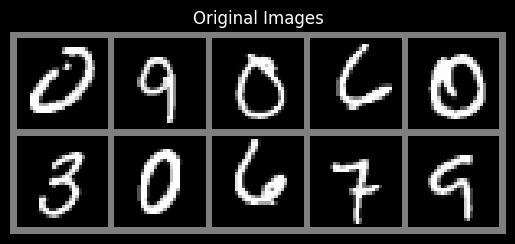

Baseline Model Reconstruction (No Context) with Noisy Input


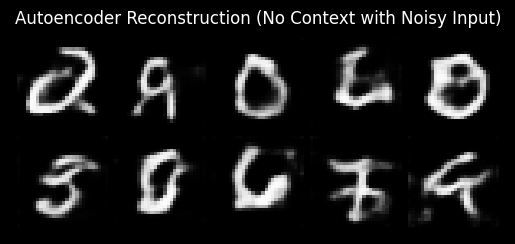

Baseline Model Reconstruction (With Context) with Noisy Input


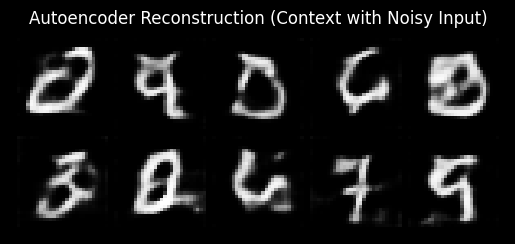

Associative Model Reconstruction (No Context) with Noisy Input


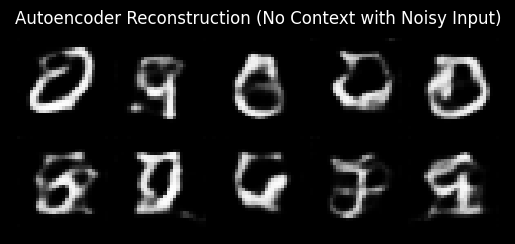

Associative Model Reconstruction (With Context) with Noisy Input


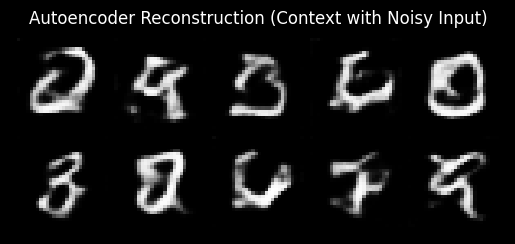

In [49]:
# Ensure inline plotting for Jupyter notebooks
%matplotlib inline

import torch
import torchvision
import matplotlib.pyplot as plt

# Helper function to rescale image for visualization
def to_img(x):
    x = 0.5 * (x + 1)  # Rescale to [0, 1]
    x = x.clamp(0, 1)
    return x

# Function to show a grid of images
def show_image(img, title=""):
    img = to_img(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Function to add noise to the images
def add_noise(images, noise_level=0.4):  # Adjust noise level as needed
    noisy_images = images + noise_level * torch.randn_like(images)
    return noisy_images.clamp(-1, 1)  # Clamp to keep values within the [-1, 1] range

# Function to visualize the model's output with noisy inputs
def visualise_output_with_noise(images, model, context_generator, context_mode="No Context", num_images=10, noise_level=0.4):
    # Set the model to evaluation mode
    model.eval()
    with torch.no_grad():
        # Apply noise to the input images
        noisy_images = add_noise(images[:num_images].to(device), noise_level)
        
        # Generate context for reconstruction (using the provided context generator)
        if context_mode == "Context":
            context = context_generator(noisy_images.size(0), high_value=1.0)
        else:
            context = torch.zeros(noisy_images.size(0), context_dim).to(device)  # No context or noisy context

        # Reconstruct images with the model and context
        reconstructed_images = model(noisy_images, context)
        reconstructed_images = reconstructed_images.cpu()
        
        # Convert to displayable format and visualize
        reconstructed_images = to_img(reconstructed_images)
        np_imagegrid = torchvision.utils.make_grid(reconstructed_images, nrow=5).numpy()
        plt.imshow(np.transpose(np_imagegrid, (1, 2, 0)))
        plt.title(f"{model.__class__.__name__} Reconstruction ({context_mode} with Noisy Input)")
        plt.axis('off')
        plt.show()

# Load a batch of images from the test set
images, labels = next(iter(test_dataloader))

# Display the original images
print("Original Images")
show_image(torchvision.utils.make_grid(images[:10], nrow=5), title="Original Images")

# Visualize reconstruction for the baseline model without contextual input (noisy images)
print("Baseline Model Reconstruction (No Context) with Noisy Input")
visualise_output_with_noise(images, baseline_autoencoder, generate_noisy_context, context_mode="No Context", noise_level=1.0)

# Visualize reconstruction for the baseline model with contextual input (noisy images)
print("Baseline Model Reconstruction (With Context) with Noisy Input")
visualise_output_with_noise(images, baseline_autoencoder, generate_associated_context, context_mode="Context", noise_level=1.0)

# Visualize reconstruction for the associative model without contextual input (noisy images)
print("Associative Model Reconstruction (No Context) with Noisy Input")
visualise_output_with_noise(images, association_autoencoder, generate_noisy_context, context_mode="No Context", noise_level=1.0)

# Visualize reconstruction for the associative model with contextual input (noisy images)
print("Associative Model Reconstruction (With Context) with Noisy Input")
visualise_output_with_noise(images, association_autoencoder, generate_associated_context, context_mode="Context", noise_level=1.0)


### Sampling from Latent Space with Contextual Influence
In this experiment, we sample random latent vectors from a multivariate normal distribution, approximated from the latent vectors of the test set. This approach aims to explore how well the autoencoder, trained with a context-based association, can reconstruct recognizable digits when guided by random latent vectors. Here, we compare reconstructions with and without the influence of a "contextual" input, observing whether the added context can bias outputs toward a specific digit or pattern.

Without context, the autoencoder attempts to reconstruct generic digits based on the latent sampling alone, resulting in variable image quality due to the sparsity and structure of the latent space. With associated context, however, we introduce a specific bias aimed at guiding the reconstruction toward certain features or digit representations, simulating the influence of multimodal association.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


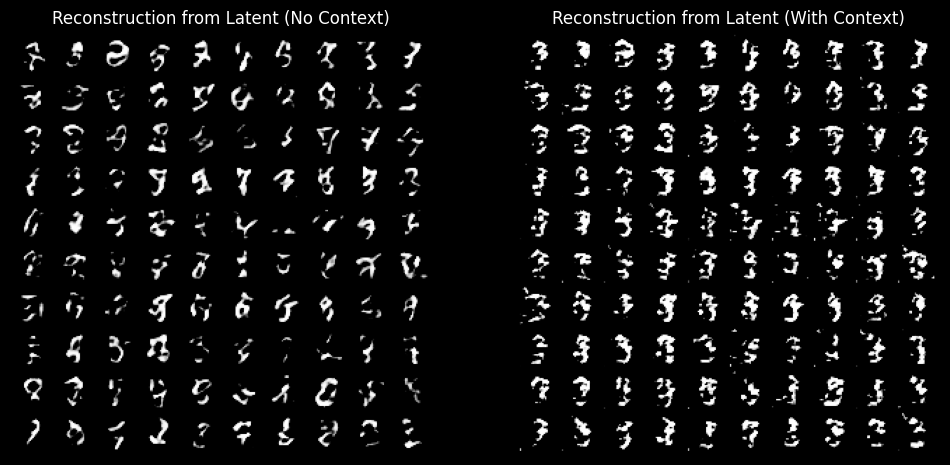

In [22]:
# Ensure evaluation mode
association_autoencoder.eval()

with torch.no_grad():
    # Sample latent vectors from a random part of the test set to approximate mean and std
    images, labels = next(iter(test_dataloader))
    images = images.to(device)
    
    # Pass through encoder with no context to approximate latent space distribution
    context_batch = torch.zeros(images.size(0), context_dim).to(device)  # No context input
    latent_no_context = association_autoencoder.encoder(images, context_batch).cpu()
    
    # Calculate mean and std of latent vectors
    mean = latent_no_context.mean(dim=0)
    std = (latent_no_context - mean).pow(2).mean(dim=0).sqrt()

    # Sample latent vectors from the estimated distribution
    latent_samples = torch.randn(128, latent_dims) * std + mean
    
    # Convert latent samples to device
    latent_samples = latent_samples.to(device)

    # Define contexts for reconstruction comparisons
    context_noisy = generate_noisy_context(latent_samples.size(0), noise_level=context_noise_level)
    context_associated = generate_associated_context(latent_samples.size(0), high_value=20.0, noise_level=context_noise_level)  

    # Reconstruct images without context
    img_recon_no_context = association_autoencoder.decoder(latent_samples, context_noisy).cpu()
    # Reconstruct images with associated context
    img_recon_with_context = association_autoencoder.decoder(latent_samples, context_associated).cpu()

    # Convert reconstructed images for display
    img_recon_no_context = torchvision.utils.make_grid(img_recon_no_context[:100], nrow=10, padding=2)
    img_recon_with_context = torchvision.utils.make_grid(img_recon_with_context[:100], nrow=10, padding=2)
    
    # Plot the reconstructions
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(img_recon_no_context.permute(1, 2, 0).numpy())
    axs[0].set_title("Reconstruction from Latent (No Context)")
    axs[0].axis('off')

    axs[1].imshow(img_recon_with_context.permute(1, 2, 0).numpy())
    axs[1].set_title("Reconstruction from Latent (With Context)")
    axs[1].axis('off')

    plt.show()

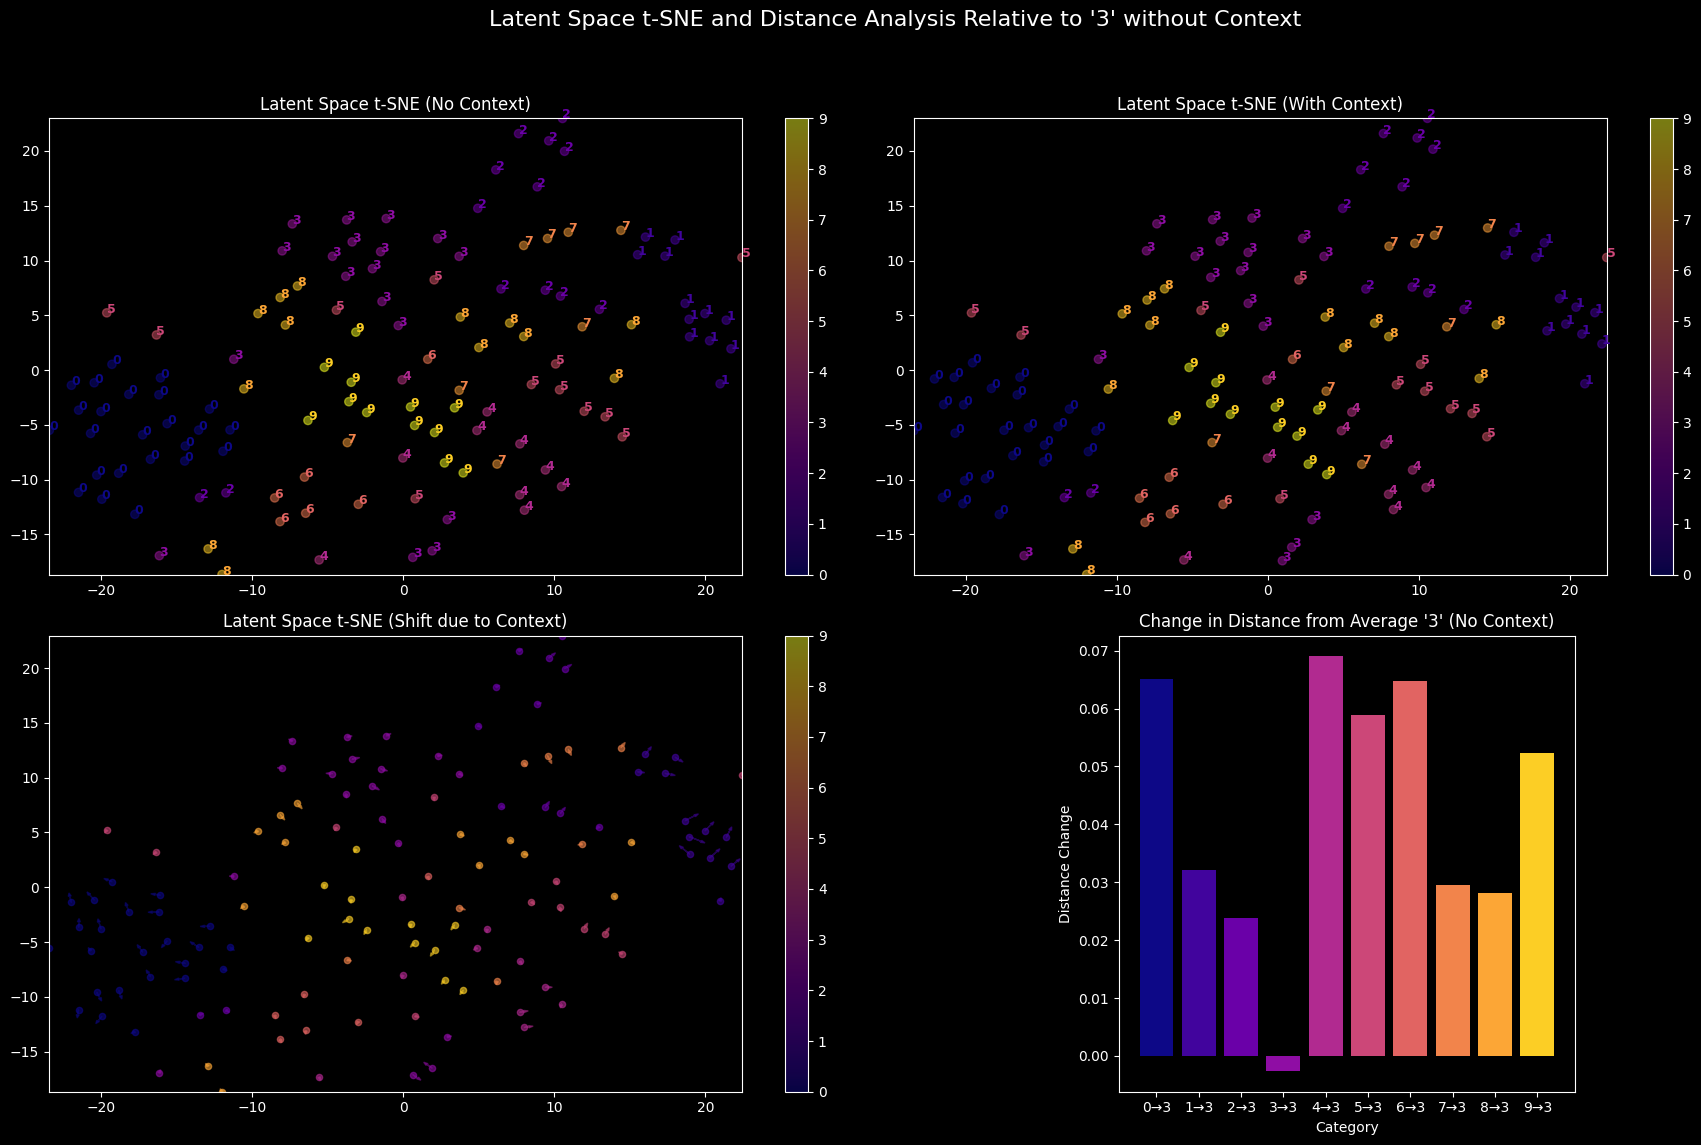

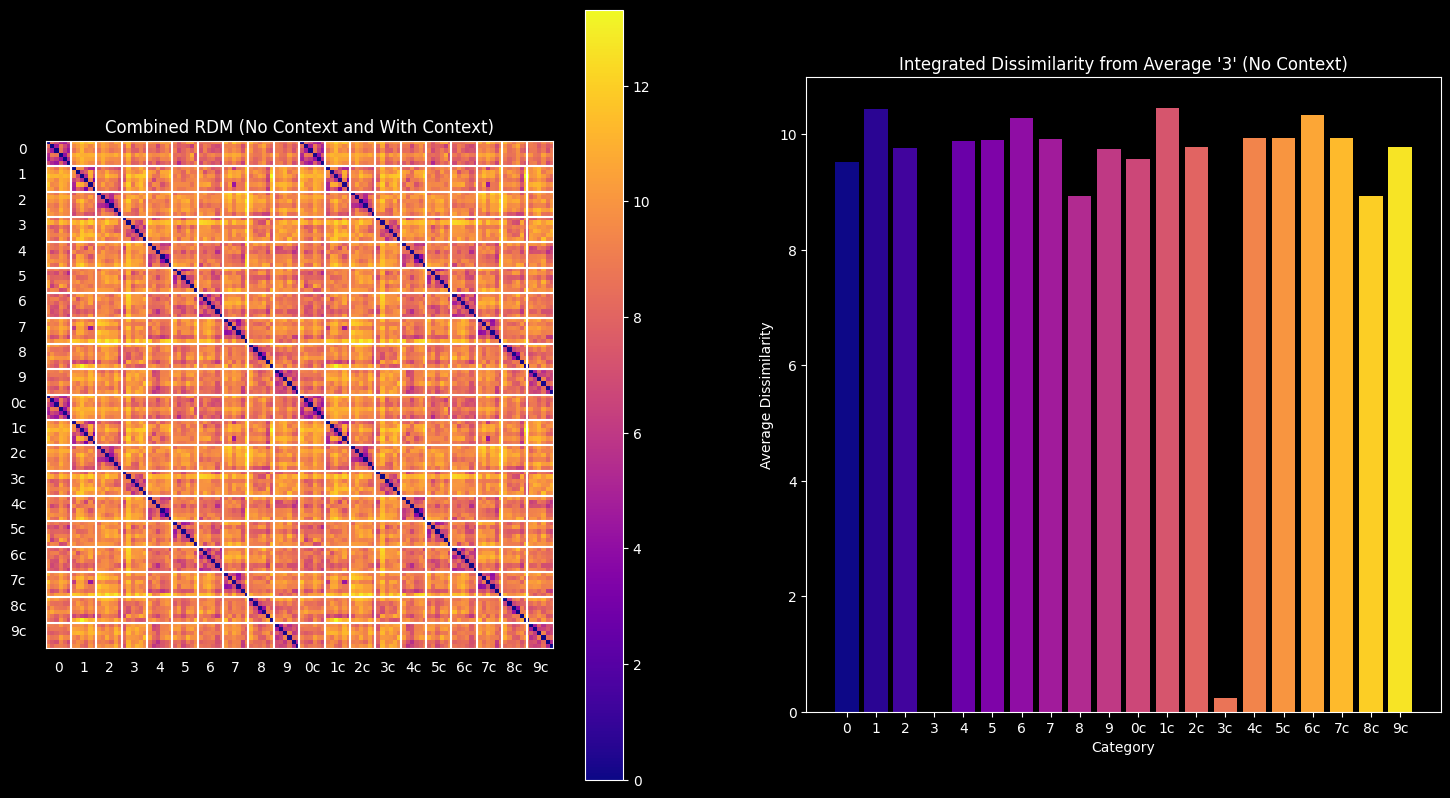

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform
import torch

# Define function to capture activations from the autoencoder
def capture_activations(model, images, context):
    with torch.no_grad():
        latent = model.encoder(images, context)
        return latent.detach().cpu().numpy()

# Load a batch of test images
images, labels = next(iter(test_dataloader))
images = images.to(device)
labels = labels.cpu().numpy()  # Convert labels to numpy array

# Generate contexts for both no-context and with-context cases
context_no_context = torch.zeros(images.size(0), context_dim).to(device)
context_with_context = generate_associated_context(images.size(0), high_value=1.0, noise_level=context_noise_level)

# Capture activations for both no-context and with-context conditions
activations_no_context = capture_activations(association_autoencoder, images, context_no_context)
activations_with_context = capture_activations(association_autoencoder, images, context_with_context)

# Calculate average activation for "3" category without context
avg_activation_3_no_context = activations_no_context[labels == 3].mean(axis=0)

# Compute change in distance from avg "3" (no context) activation for each digit
distance_diffs = [
    np.linalg.norm(activations_with_context[labels == i] - avg_activation_3_no_context, axis=1).mean() -
    np.linalg.norm(activations_no_context[labels == i] - avg_activation_3_no_context, axis=1).mean()
    for i in range(10)
]

# Perform a single t-SNE on the combined latent space (with and without context)
combined_activations = np.concatenate([activations_no_context, activations_with_context], axis=0)
combined_labels = np.concatenate([labels, labels + 10])  # Separate labels for with-context by adding 10

tsne = TSNE(n_components=2, random_state=0)
combined_tsne = tsne.fit_transform(combined_activations)

# Split t-SNE results back into no-context and with-context
latent_no_context_tsne = combined_tsne[:len(activations_no_context)]
latent_with_context_tsne = combined_tsne[len(activations_no_context):]

# Set axis limits for synchronized t-SNE plots
x_min, x_max = combined_tsne[:, 0].min(), combined_tsne[:, 0].max()
y_min, y_max = combined_tsne[:, 1].min(), combined_tsne[:, 1].max()

# Plot t-SNE with arrows showing shift due to context
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Latent Space t-SNE and Distance Analysis Relative to '3' without Context", fontsize=16)

# t-SNE plot without context
axs[0, 0].set_title("Latent Space t-SNE (No Context)")
scatter = axs[0, 0].scatter(latent_no_context_tsne[:, 0], latent_no_context_tsne[:, 1], c=labels, cmap='plasma', alpha=0.5)
for i, (x, y) in enumerate(latent_no_context_tsne):
    axs[0, 0].text(x, y, str(labels[i]), color=plt.cm.plasma(labels[i] / 10), fontdict={'weight': 'bold', 'size': 9})
axs[0, 0].figure.colorbar(scatter, ax=axs[0, 0], ticks=range(10))
axs[0, 0].set_xlim(x_min, x_max)
axs[0, 0].set_ylim(y_min, y_max)

# t-SNE plot with context
axs[0, 1].set_title("Latent Space t-SNE (With Context)")
scatter = axs[0, 1].scatter(latent_with_context_tsne[:, 0], latent_with_context_tsne[:, 1], c=labels, cmap='plasma', alpha=0.5)
for i, (x, y) in enumerate(latent_with_context_tsne):
    axs[0, 1].text(x, y, str(labels[i]), color=plt.cm.plasma(labels[i] / 10), fontdict={'weight': 'bold', 'size': 9})
axs[0, 1].figure.colorbar(scatter, ax=axs[0, 1], ticks=range(10))
axs[0, 1].set_xlim(x_min, x_max)
axs[0, 1].set_ylim(y_min, y_max)

# t-SNE plot showing arrows to indicate the shift
axs[1, 0].set_title("Latent Space t-SNE (Shift due to Context)")
for i, (x_no_context, y_no_context) in enumerate(latent_no_context_tsne):
    x_with_context, y_with_context = latent_with_context_tsne[i]
    axs[1, 0].arrow(x_no_context, y_no_context, x_with_context - x_no_context, y_with_context - y_no_context,
                    color=plt.cm.plasma(labels[i] / 10), head_width=0.2, alpha=0.5)
    axs[1, 0].scatter(x_no_context, y_no_context, color=plt.cm.plasma(labels[i] / 10), s=20, alpha=0.6)
axs[1, 0].figure.colorbar(scatter, ax=axs[1, 0], ticks=range(10))
axs[1, 0].set_xlim(x_min, x_max)
axs[1, 0].set_ylim(y_min, y_max)

# Histogram of changes in distance from average "3" (no context)
categories = [str(i) + "→3" for i in range(10)]
axs[1, 1].bar(range(10), distance_diffs, color=plt.cm.plasma(np.arange(10) / 10))
axs[1, 1].set_xticks(range(10))
axs[1, 1].set_xticklabels(categories)
axs[1, 1].set_title("Change in Distance from Average '3' (No Context)")
axs[1, 1].set_xlabel("Category")
axs[1, 1].set_ylabel("Distance Change")
axs[1, 1].set_box_aspect(1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# RDM Analysis with combined labels and balanced samples per category
samples_per_class = min(len(labels[labels == i]) for i in range(10))  # Minimum samples per class
balanced_indices = np.concatenate([
    np.random.choice(np.where(labels == i)[0], samples_per_class, replace=False) for i in range(10)
])
balanced_no_context = activations_no_context[balanced_indices]
balanced_with_context = activations_with_context[balanced_indices]
balanced_combined_activations = np.concatenate([balanced_no_context, balanced_with_context], axis=0)
balanced_combined_labels = np.concatenate([labels[balanced_indices], labels[balanced_indices] + 10])

# Compute the integrated dissimilarity from the "3" (no context) for RDM
rdm_combined = squareform(pdist(balanced_combined_activations, 'euclidean'))
avg_3_dissimilarities = [
    rdm_combined[balanced_combined_labels == 3, balanced_combined_labels == i].mean()
    for i in range(10)
] + [
    rdm_combined[balanced_combined_labels == 3, balanced_combined_labels == i + 10].mean()
    for i in range(10)
]

# Prepare labels for the histogram and RDM plot
categories = [str(i) for i in range(10)] + [str(i) + "c" for i in range(10)]

# Plot the combined RDM with labels on the side
fig, ax = plt.subplots(1, 2, figsize=(18, 10))
ax[0].set_title("Combined RDM (No Context and With Context)")
rdm_plot_combined = ax[0].imshow(rdm_combined, cmap='plasma', interpolation='nearest')
fig.colorbar(rdm_plot_combined, ax=ax[0])

# Add separators and labels to the combined RDM
for i in range(20):  # 10 original classes + 10 context-modified classes
    ax[0].axhline(i * samples_per_class - 0.5, color='white', linewidth=1.5)
    ax[0].axvline(i * samples_per_class - 0.5, color='white', linewidth=1.5)
    label_text = str(i % 10) + ("c" if i >= 10 else "")
    ax[0].text(-5, i * samples_per_class + samples_per_class / 2 - 0.5, label_text, color="white", fontsize=10, ha='right')
    ax[0].text(i * samples_per_class + samples_per_class / 2 - 0.5, len(balanced_combined_labels) + 5, label_text, color="white", fontsize=10, ha='center')

# Remove row and column tick labels
ax[0].set_xticks([])
ax[0].set_yticks([])

# Plot integrated dissimilarity from "3" for each category (no context vs with context)
ax[1].bar(range(20), avg_3_dissimilarities, color=plt.cm.plasma(np.arange(20) / 20))
ax[1].set_xticks(range(20))
ax[1].set_xticklabels(categories)
ax[1].set_title("Integrated Dissimilarity from Average '3' (No Context)")
ax[1].set_xlabel("Category")
ax[1].set_ylabel("Average Dissimilarity")
ax[1].set_box_aspect(1)

plt.show()

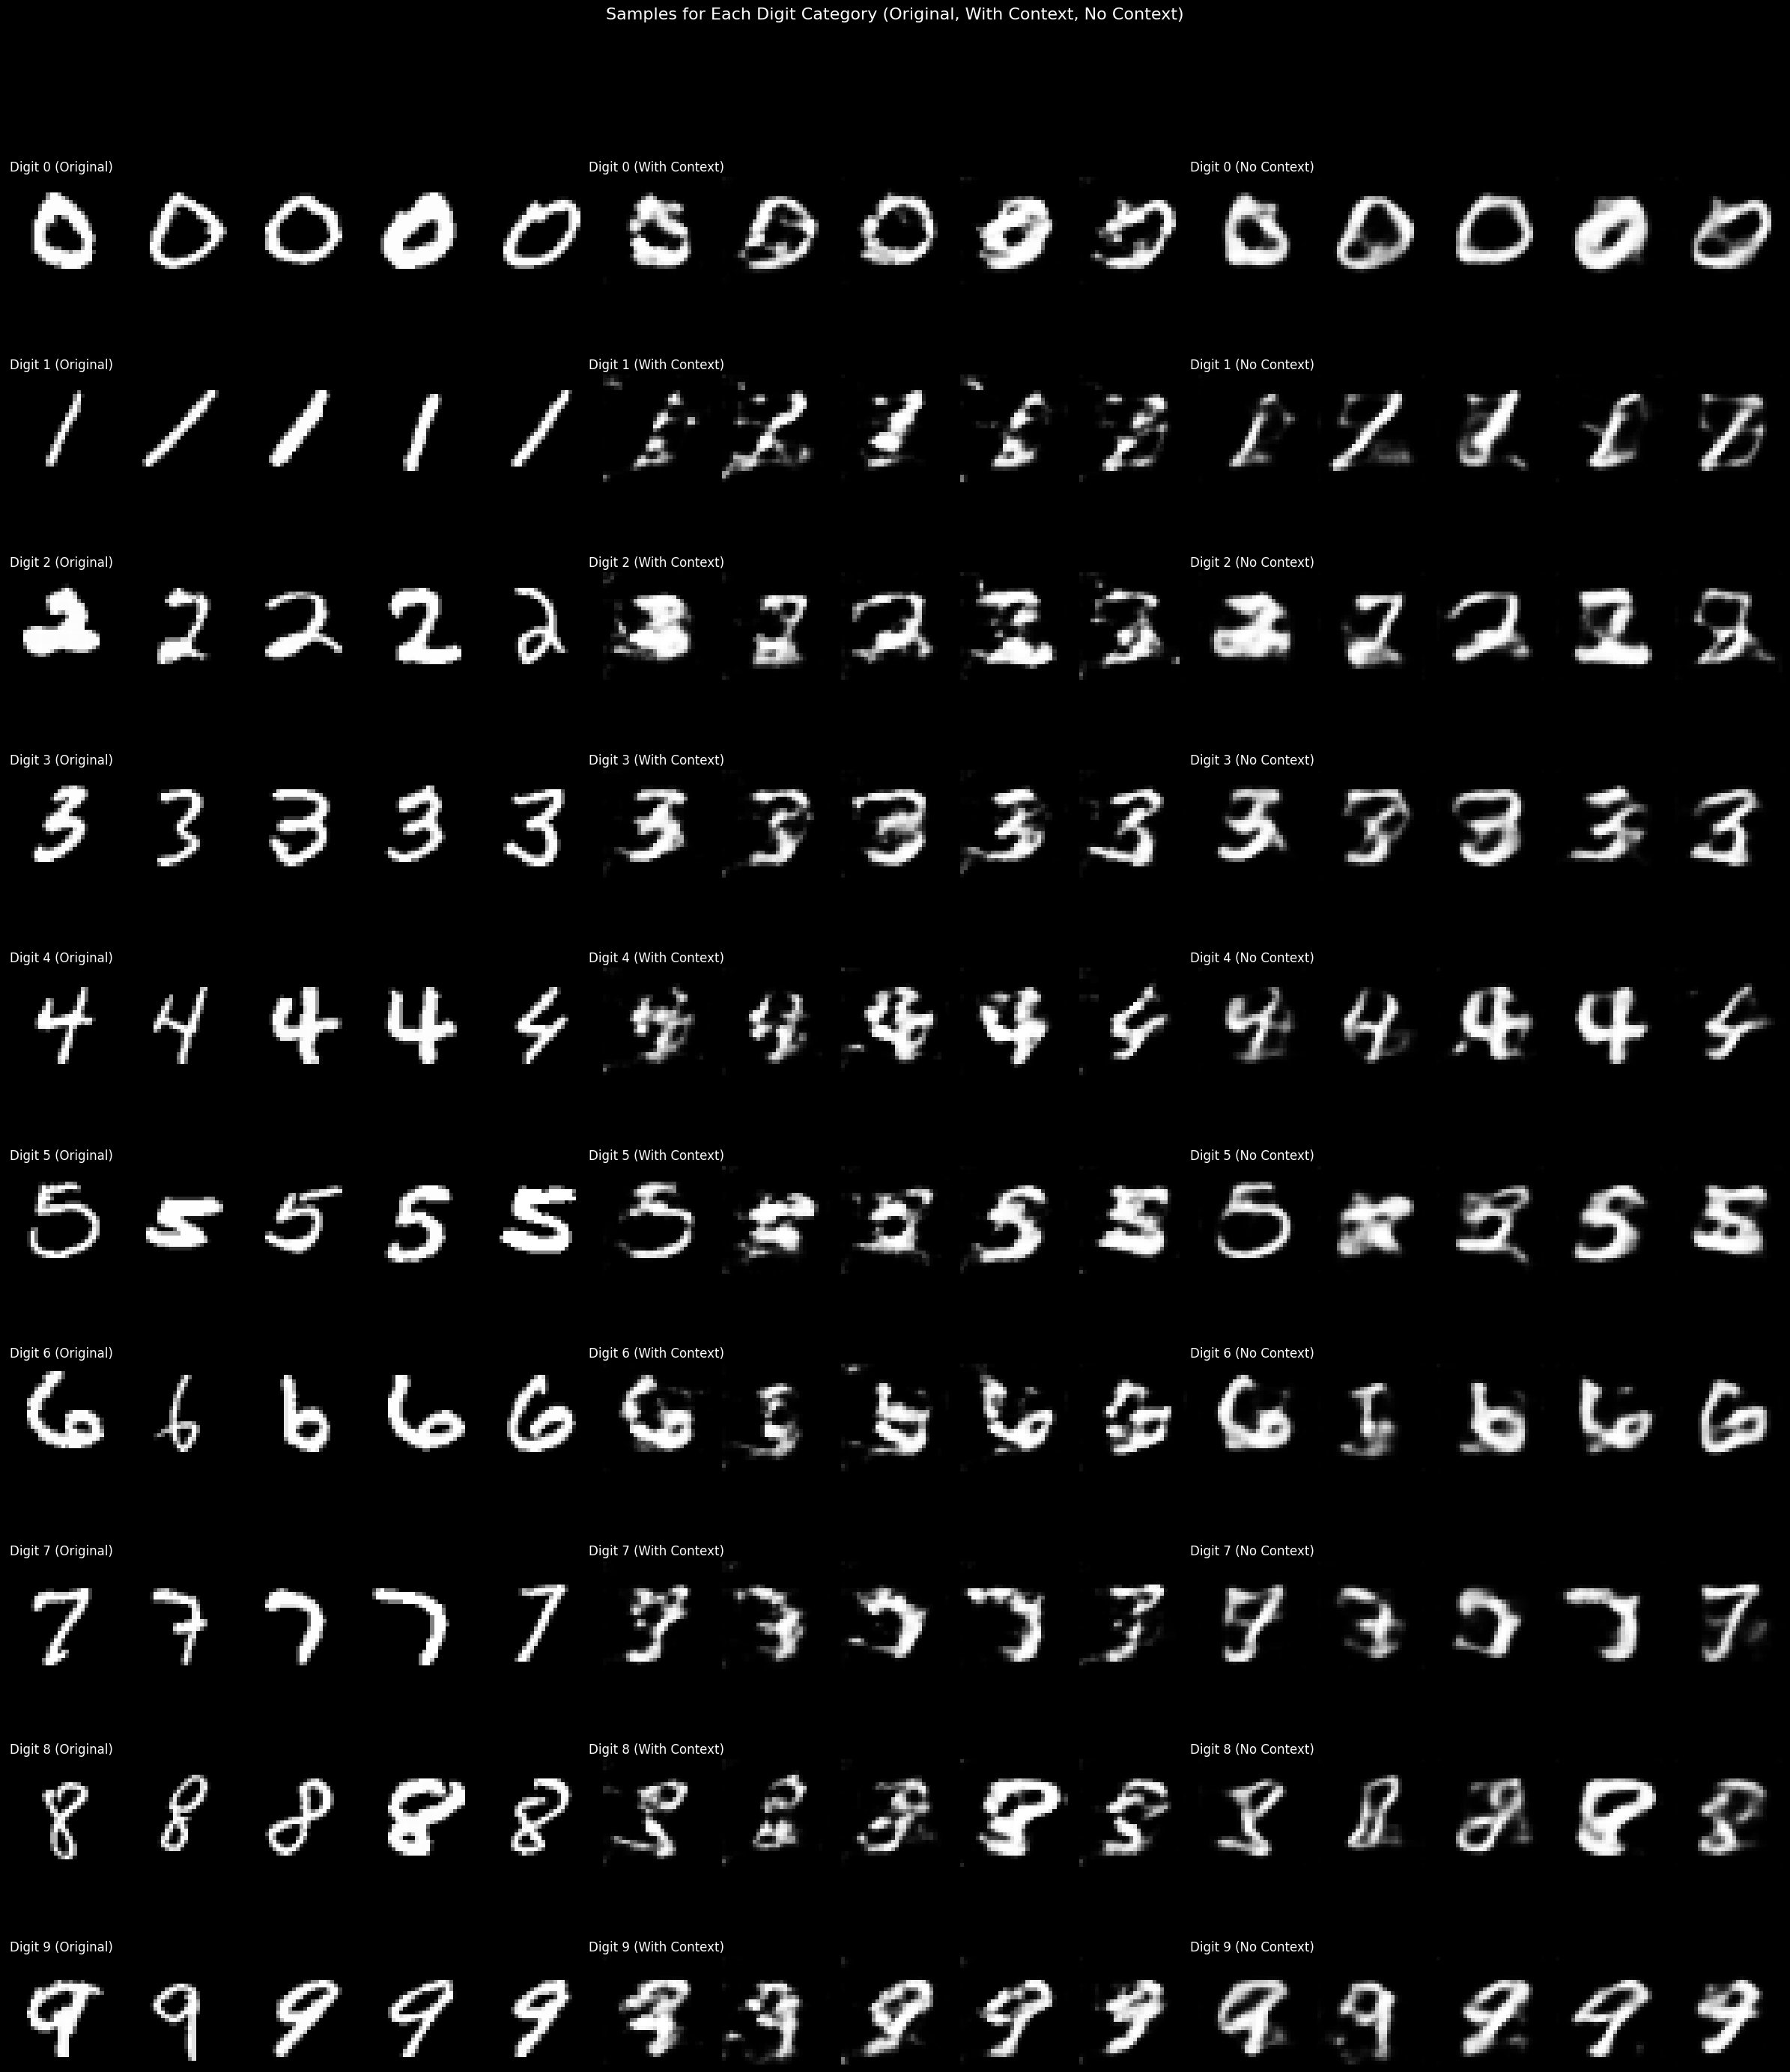

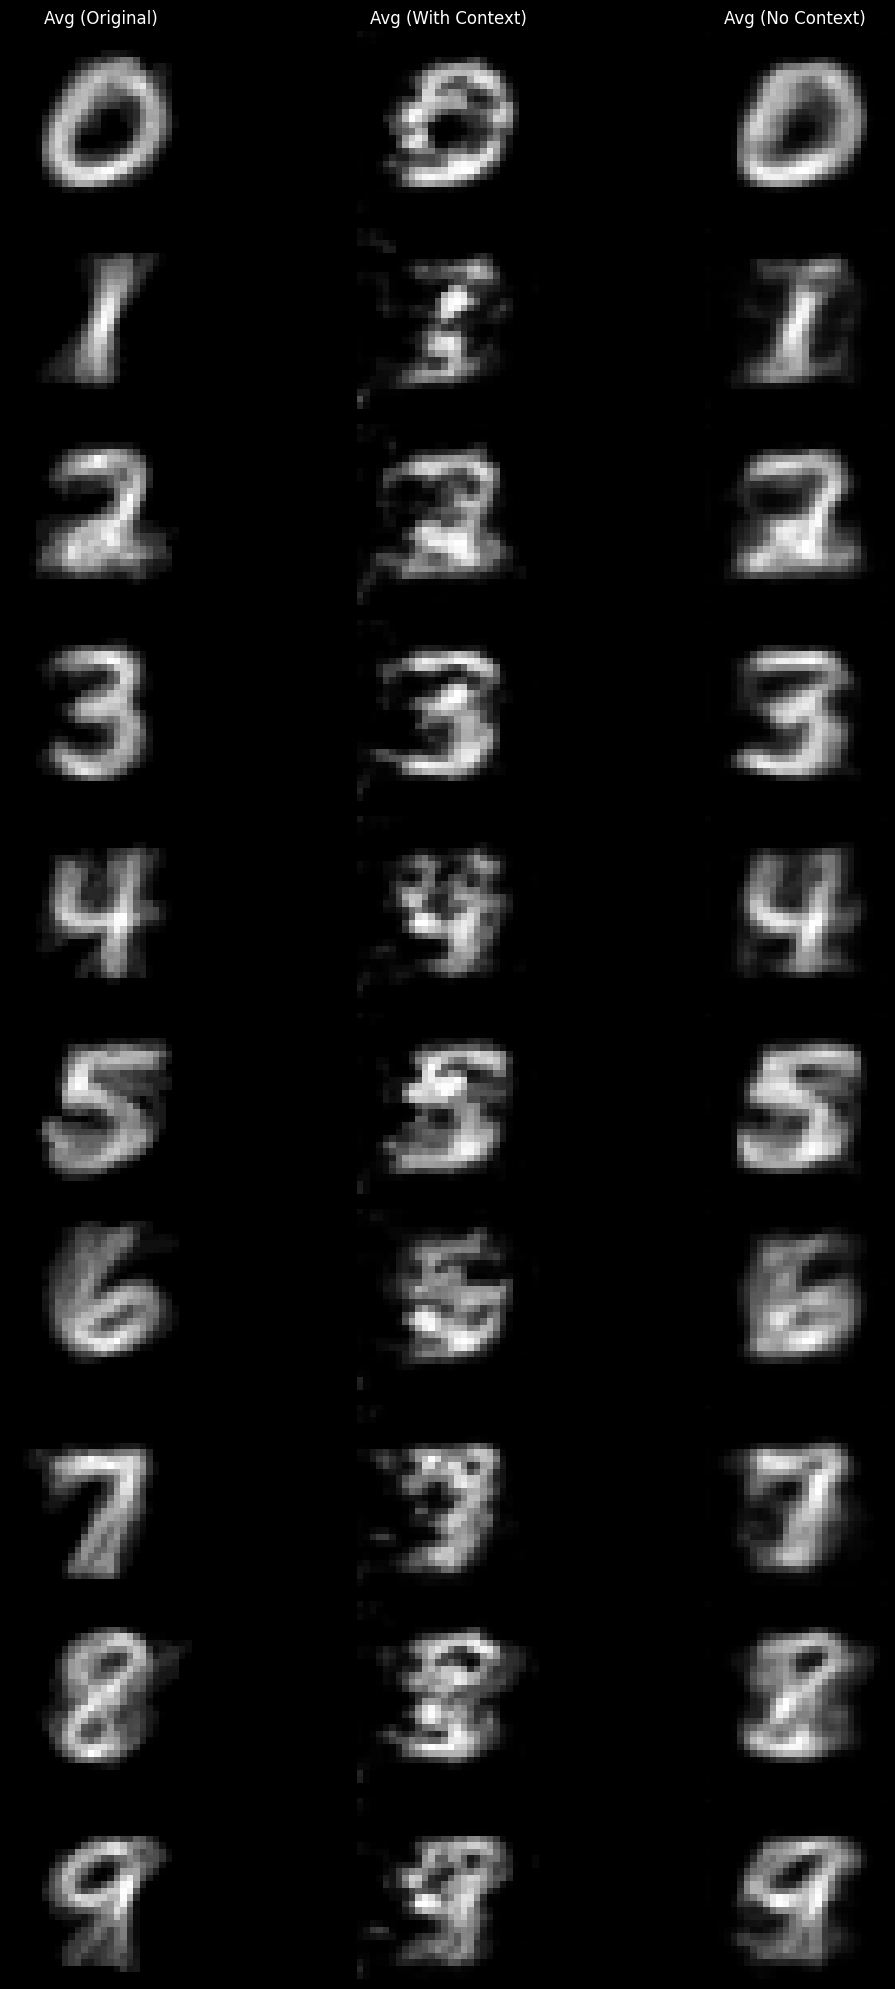

In [109]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision

# Ensure the model is in evaluation mode
association_autoencoder.eval()

# Function to add noise to images
def add_noise(images, noise_level=0.5):
    noisy_images = images + noise_level * torch.randn_like(images)
    return torch.clamp(noisy_images, -1, 1)  # Ensure pixel values stay in the range [-1, 1]

# Function to capture reconstructions
def get_reconstructed_images(model, images, context):
    with torch.no_grad():
        reconstructions = model(images, context)
        return reconstructions.detach().cpu().numpy()

# Load a batch of test images and labels
images, labels = next(iter(test_dataloader))
images = images.to(device)

# Apply noise to the images
noisy_images = add_noise(images, noise_level=0.95)  # Adjust noise level as needed

# Generate contexts for the noisy images
context_with_noise = generate_associated_context(noisy_images.size(0), high_value=7.5)
context_no_context = generate_noisy_context(noisy_images.size(0), noise_level=0.0)

# Capture reconstructions with and without context
reconstructions_with_context = get_reconstructed_images(association_autoencoder, noisy_images, context_with_noise)
reconstructions_no_context = get_reconstructed_images(association_autoencoder, noisy_images, context_no_context)

# Number of samples to show per category
num_samples = 5

# Plot samples for each digit category
fig, axes = plt.subplots(10, num_samples * 3, figsize=(24, 30))
fig.suptitle("Samples for Each Digit Category (Original, With Context, No Context)", fontsize=16)

for i in range(10):
    # Get indices for the first few samples of each digit
    indices = np.where(labels == i)[0][:num_samples]

    for j, idx in enumerate(indices):
        # Original samples
        axes[i, j].imshow(images[idx].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f'Digit {i} (Original)')

        # Reconstruction with context
        axes[i, j + num_samples].imshow(reconstructions_with_context[idx].reshape(28, 28), cmap='gray')
        axes[i, j + num_samples].axis('off')
        if j == 0:
            axes[i, j + num_samples].set_title(f'Digit {i} (With Context)')

        # Reconstruction without context (high noise)
        axes[i, j + 2 * num_samples].imshow(reconstructions_no_context[idx].reshape(28, 28), cmap='gray')
        axes[i, j + 2 * num_samples].axis('off')
        if j == 0:
            axes[i, j + 2 * num_samples].set_title(f'Digit {i} (No Context)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plot average templates for each digit in a separate plot
fig, axes_avg = plt.subplots(10, 3, figsize=(12, 20))  # Adjusted for 10 rows and a smaller size

for i in range(10):  # Iterate over digit categories
    for j in range(3):  # 3 conditions: Original, With Context, No Context
        indices = np.where(labels == i)[0]
        
        if j == 0:  # Original
            avg_image = images[indices].mean(dim=0).cpu().numpy()
            axes_avg[i, j].imshow(avg_image.reshape(28, 28), cmap='gray')
            if i == 0:
                axes_avg[i, j].set_title('Avg (Original)')
        elif j == 1:  # With Context
            avg_image = reconstructions_with_context[indices].mean(axis=0)
            axes_avg[i, j].imshow(avg_image.reshape(28, 28), cmap='gray')
            if i == 0:
                axes_avg[i, j].set_title('Avg (With Context)')
        elif j == 2:  # No Context
            avg_image = reconstructions_no_context[indices].mean(axis=0)
            axes_avg[i, j].imshow(avg_image.reshape(28, 28), cmap='gray')
            if i == 0:
                axes_avg[i, j].set_title('Avg (No Context)')
        
        axes_avg[i, j].axis('off')
        if j == 0:
            axes_avg[i, j].set_ylabel(f'Digit {i}', fontsize=12)

plt.tight_layout()
plt.show()
